In [11]:
%run 0_config.ipynb

In [2]:
for L in range(2,11,2):
    mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
    print(L,mens,exact_gs_energy)

2 The exact ground-state energy is ferromag E0= -1.0
4 The exact ground-state energy is ferromag E0= -4.000000000000002
6 The exact ground-state energy is ferromag E0= -6.000000000000005
8 The exact ground-state energy is ferromag E0= -8.00000000000001
10 The exact ground-state energy is ferromag E0= -9.999999999999991


In [3]:
for L in range(2,7,2):
    exact_gs_energy,r_out = jastrow_calc(0,L,600,True)
    print("L:", L, " | ",mens,exact_gs_energy)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 2  |  The exact ground-state energy is ferromag E0= -0.9999999999999969


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 4  |  The exact ground-state energy is ferromag E0= -4.0


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 6  |  The exact ground-state energy is ferromag E0= -6.000001250253367


In [4]:
for L in range(2,7,2):
    g_run,r_out = rbm(0,L,1200,True)
    print("L:", L, " | ",mens,float(g_run.energy.mean.real))

  0%|                                                            | 0/1200 [00:00<?, ?it/s]

L: 2  |  The exact ground-state energy is ferromag E0= -3.0


  0%|                                                            | 0/1200 [00:00<?, ?it/s]

L: 4  |  The exact ground-state energy is ferromag E0= -7.999999997977196


  0%|                                                            | 0/1200 [00:00<?, ?it/s]

L: 6  |  The exact ground-state energy is ferromag E0= -11.211080522412882


Esse é o <b< Hamiltoniano ferromagnético </b>, mas a RBM foi projetada originalmente para representar estados altamente correlacionados como os antiferromagnéticos — e não estados trivialmente alinhados como o ferromagnético.

In [5]:
for L in range(2,7,2):
    g_run,r_out = rbm_fe(0,L,600,True,)
    print("L:", L, " | ",mens,float(g_run.energy.mean.real))

  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 2  |  The exact ground-state energy is ferromag E0= -1.0


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 4  |  The exact ground-state energy is ferromag E0= -4.0


  0%|                                                             | 0/600 [00:00<?, ?it/s]

L: 6  |  The exact ground-state energy is ferromag E0= -6.0


- Espaço de Hilbert completo (o modelo pode acessar o setor $ S^z = +N/2$ <br />
- sampler que explora todos os setores <br />
- otimizador funcional <br />
- A RBM é capaz de aprender que o estado de menor energia é o com todos os spins alinhados, o que é trivial para ela (uma configuração dominante)

In [184]:
%run 0_config.ipynb

In [208]:
df_kernel_real = pd.read_csv(paths[2])
df = df_kernel_real

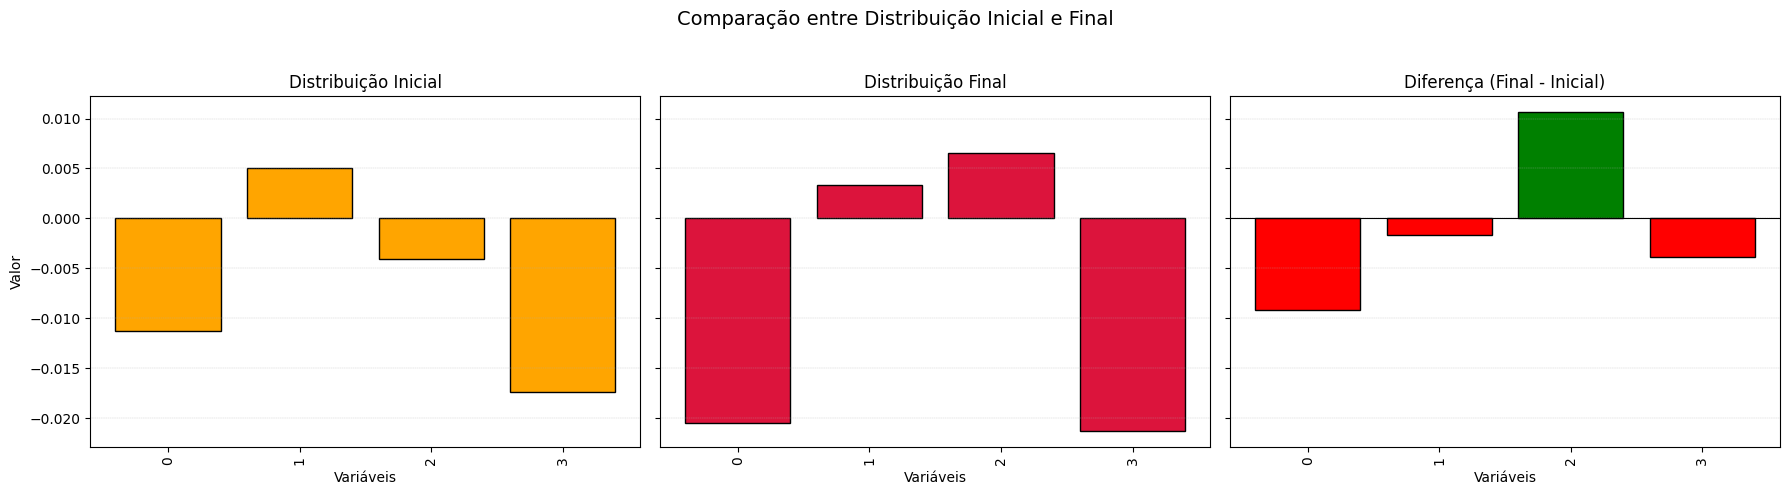

In [206]:
# Pega a primeira e última linha, ignorando a primeira coluna
linha1 = df.iloc[0].iloc[1:]
ultima_linha = df.iloc[-1].iloc[1:]

# Calcula a diferença entre as linhas
diferenca = ultima_linha - linha1

# Cria uma figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da diferença
axes[2].bar(diferenca.index, diferenca.values, 
            color=np.where(diferenca.values >= 0, 'green', 'red'),  # Verde para positivo, vermelho para negativo
            edgecolor='black')
axes[2].set_title("Diferença (Final - Inicial)", fontsize=12)
axes[2].set_xlabel("Variáveis", fontsize=10)
axes[2].tick_params(axis='x', rotation=90)
axes[2].grid(axis='y', lw=0.3, ls='--', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)  # Linha no zero para referência

# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [201]:
import matplotlib.gridspec as gridspec

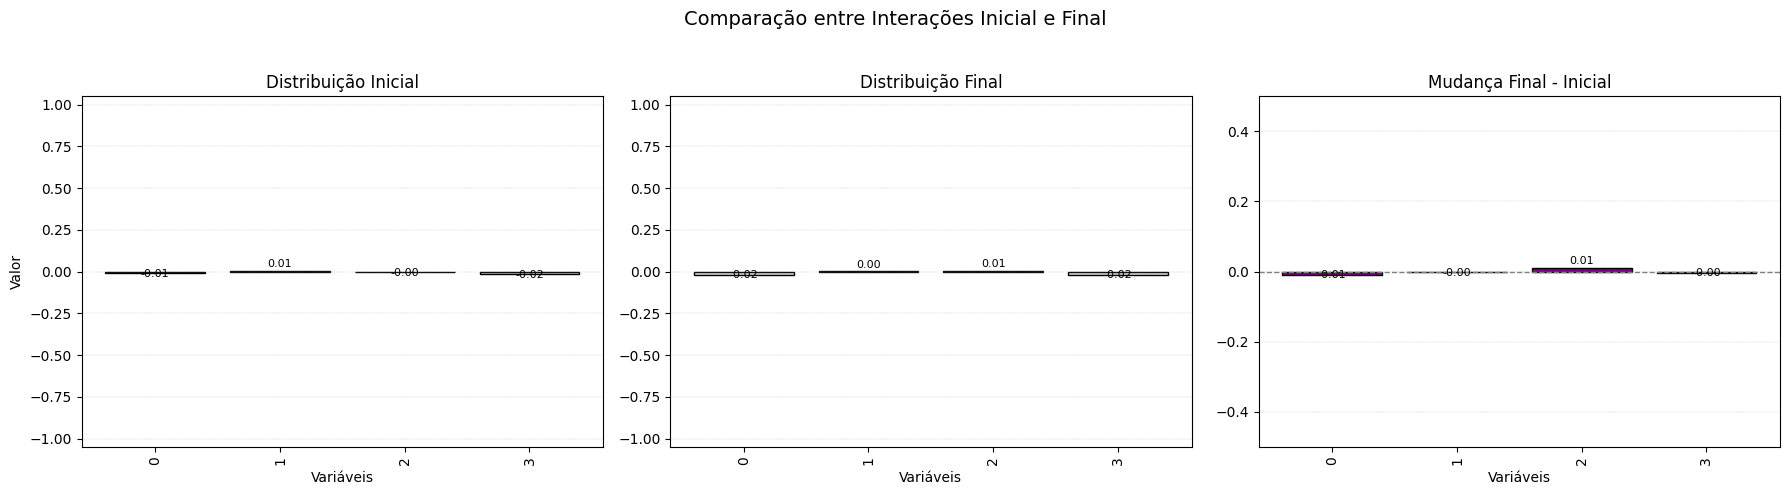

In [202]:
# --- Seleciona os dados ---
linha1 = df.iloc[0].iloc[1:]          # Primeira linha sem a primeira coluna
ultima_linha = df.iloc[-1].iloc[1:]   # Última linha sem a primeira coluna
diff = ultima_linha - linha1          # Diferença final - inicial

# --- Prepara a figura com 3 gráficos em linha ---
fig = plt.figure(figsize=(18, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1])

# --- 1. Gráfico: distribuição inicial ---
ax0 = fig.add_subplot(gs[0])
colors0 = plt.cm.coolwarm((linha1.values - (-1)) / 2)  # normaliza -1 a 1 para [0,1]
ax0.bar(linha1.index, linha1.values, color=colors0, edgecolor='black')
for i, v in enumerate(linha1.values):
    ax0.text(i, v + 0.02 * np.sign(v), f"{v:.2f}", ha='center', fontsize=8)
ax0.set_ylim(-1.05, 1.05)
ax0.set_title("Distribuição Inicial", fontsize=12)
ax0.set_xlabel("Variáveis"); ax0.set_ylabel("Valor")
ax0.tick_params(axis='x', rotation=90)
ax0.grid(axis='y', linestyle='--', lw=0.3, alpha=0.7)

# --- 2. Gráfico: distribuição final ---
ax1 = fig.add_subplot(gs[1])
colors1 = plt.cm.coolwarm((ultima_linha.values - (-1)) / 2)
ax1.bar(ultima_linha.index, ultima_linha.values, color=colors1, edgecolor='black')
for i, v in enumerate(ultima_linha.values):
    ax1.text(i, v + 0.02 * np.sign(v), f"{v:.2f}", ha='center', fontsize=8)
ax1.set_ylim(-1.05, 1.05)
ax1.set_title("Distribuição Final", fontsize=12)
ax1.set_xlabel("Variáveis")
ax1.tick_params(axis='x', rotation=90)
ax1.grid(axis='y', linestyle='--', lw=0.3, alpha=0.7)

# --- 3. Gráfico: diferença entre final e inicial ---
ax2 = fig.add_subplot(gs[2])
ax2.bar(diff.index, diff.values, color='purple', edgecolor='black')
for i, v in enumerate(diff.values):
    ax2.text(i, v + 0.01 * np.sign(v), f"{v:.2f}", ha='center', fontsize=8)
ax2.axhline(0, color='gray', linestyle='--', lw=1)
ax2.set_ylim(-0.5, 0.5)
ax2.set_title("Mudança Final - Inicial", fontsize=12)
ax2.set_xlabel("Variáveis")
ax2.tick_params(axis='x', rotation=90)
ax2.grid(axis='y', linestyle='--', lw=0.3, alpha=0.7)

# --- Layout final ---
plt.suptitle("Comparação entre Interações Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


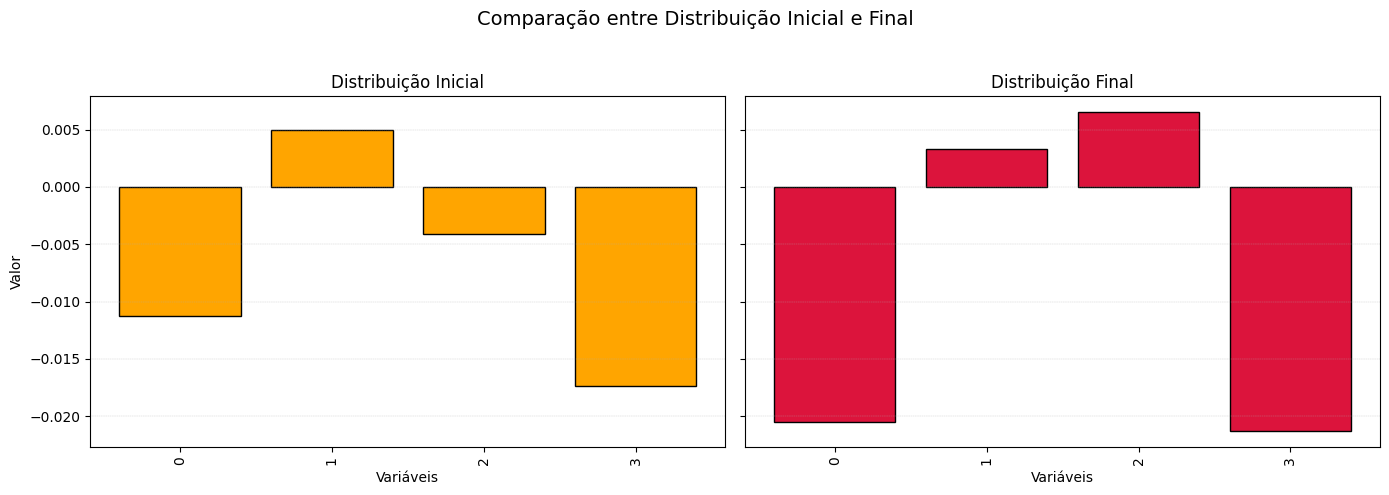

In [205]:
# Pega a primeira e última linha, ignorando a primeira coluna
linha1 = df.iloc[0].iloc[1:]
ultima_linha = df.iloc[-1].iloc[1:]

# Cria uma figura com 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)



# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [214]:
L = 22; it = 600; trained_params_list = []; parameters_list = [];iii = [] 
g_run_cc_energy,r_out, paths = rbm_fe(0,L,it,True,1)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

In [217]:
df.shape

(600, 485)

In [221]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 25.6 MB/s eta 0:00:000:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]


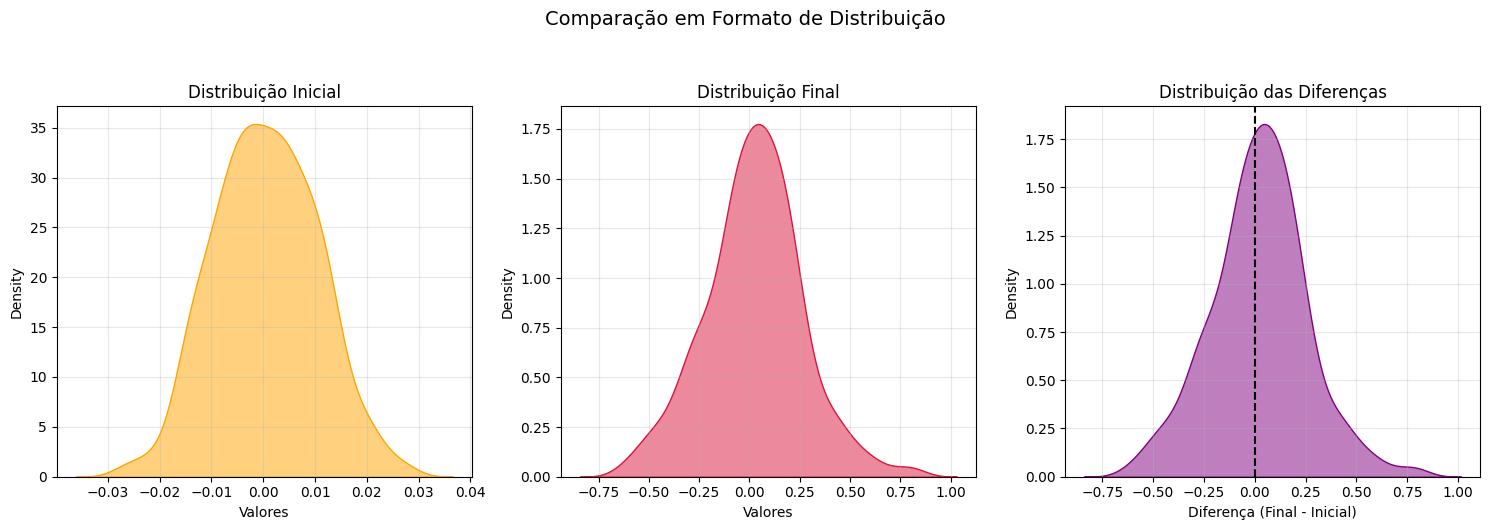

In [225]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Supondo que:
# linha1 = valores iniciais (ex: pd.Series)
# ultima_linha = valores finais
diferenca = ultima_linha - linha1

# Cria figura com 3 subplots no estilo "distribuição"
plt.figure(figsize=(15, 5))

# Subplot 1: Distribuição Inicial
plt.subplot(1, 3, 1)
sns.kdeplot(linha1, color='orange', fill=True, alpha=0.5)
plt.title('Distribuição Inicial', fontsize=12)
plt.xlabel('Valores')
plt.grid(alpha=0.3)

# Subplot 2: Distribuição Final
plt.subplot(1, 3, 2)
sns.kdeplot(ultima_linha, color='crimson', fill=True, alpha=0.5)
plt.title('Distribuição Final', fontsize=12)
plt.xlabel('Valores')
plt.grid(alpha=0.3)

# Subplot 3: Diferenças
plt.subplot(1, 3, 3)
sns.kdeplot(diferenca, color='purple', fill=True, alpha=0.5)
plt.axvline(0, color='black', linestyle='--')
plt.title('Distribuição das Diferenças', fontsize=12)
plt.xlabel('Diferença (Final - Inicial)')
plt.grid(alpha=0.3)

plt.suptitle('Comparação em Formato de Distribuição', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

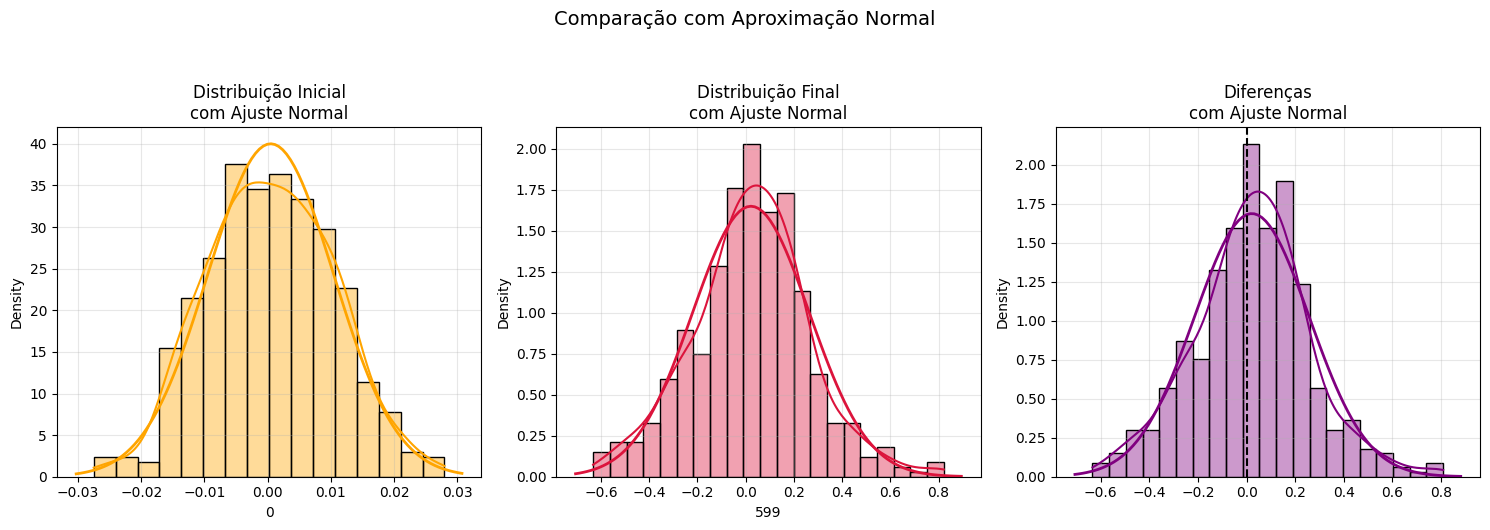

In [226]:
from scipy.stats import norm

plt.figure(figsize=(15, 5))

# Função para plotar com overlay de curva normal
def plot_with_normal(ax, data, color, title):
    sns.histplot(data, kde=True, color=color, ax=ax, stat='density', alpha=0.4)
    mu, std = norm.fit(data)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    ax.plot(x, p, color=color, linewidth=2)
    ax.set_title(title)
    ax.grid(alpha=0.3)

# Plotagem
ax1 = plt.subplot(1, 3, 1)
plot_with_normal(ax1, linha1, 'orange', 'Distribuição Inicial\ncom Ajuste Normal')

ax2 = plt.subplot(1, 3, 2)
plot_with_normal(ax2, ultima_linha, 'crimson', 'Distribuição Final\ncom Ajuste Normal')

ax3 = plt.subplot(1, 3, 3)
plot_with_normal(ax3, diferenca, 'purple', 'Diferenças\ncom Ajuste Normal')
ax3.axvline(0, color='black', linestyle='--')

plt.suptitle('Comparação com Aproximação Normal', y=1.05, fontsize=14)
plt.tight_layout()
plt.show()

In [228]:
import plotly.express as px

# Cria DataFrame para plotagem
df_plot = pd.DataFrame({
    'Inicial': linha1,
    'Final': ultima_linha,
    'Diferença': diferenca
}).melt(var_name='Tipo', value_name='Valor')

# Plot
fig = px.histogram(df_plot, 
                   x='Valor', 
                   color='Tipo',
                   marginal='rug',
                   nbins=50,
                   facet_col='Tipo',
                   color_discrete_map={
                       'Inicial': 'orange',
                       'Final': 'crimson',
                       'Diferença': 'purple'
                   },
                   title='Distribuições Comparadas')

fig.update_layout(barmode='overlay')
fig.update_traces(opacity=0.7)
fig.show()

In [224]:
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Calcula diferenças
diferenca = ultima_linha - linha1

# Top 50 maiores diferenças (absolutas)
top_diff = diferenca.abs().nlargest(50).index
diferenca_top = diferenca[top_diff].sort_values()

# Cria figura com subplots
fig = make_subplots(rows=1, cols=3, 
                   subplot_titles=("Distribuição Inicial", 
                                  "Distribuição Final", 
                                  "Diferença (Final - Inicial)"))

# Adiciona traços
fig.add_trace(
    go.Bar(x=linha1[top_diff][diferenca_top.index],
           y=diferenca_top.index,
           orientation='h',
           name='Inicial',
           marker_color='orange'),
    row=1, col=1)

fig.add_trace(
    go.Bar(x=ultima_linha[top_diff][diferenca_top.index],
           y=diferenca_top.index,
           orientation='h',
           name='Final',
           marker_color='crimson'),
    row=1, col=2)

fig.add_trace(
    go.Bar(x=diferenca_top,
           y=diferenca_top.index,
           orientation='h',
           name='Diferença',
           marker_color=['green' if x >=0 else 'red' for x in diferenca_top]),
    row=1, col=3)

# Ajustes de layout
fig.update_layout(
    height=800,
    width=1400,
    title_text=f"Top 50 Variáveis com Maiores Diferenças (de {len(diferenca)} totais)",
    showlegend=False
)

# Ajusta eixos Y sincronizados
fig.update_yaxes(autorange="reversed", row=1, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=2)
fig.update_yaxes(autorange="reversed", row=1, col=3)

fig.show()

In [223]:
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'notebook'  # Ou 'browser' se estiver em IDE

fig = px.bar(diferenca.nlargest(50).reset_index(), 
             x='index', y=0, 
             title='Top 50 Diferenças',
             labels={'index':'Variável', '0':'Diferença'})
fig.update_layout(xaxis_tickangle=-90)
fig.show()

In [215]:
df = pd.read_csv(paths[2])

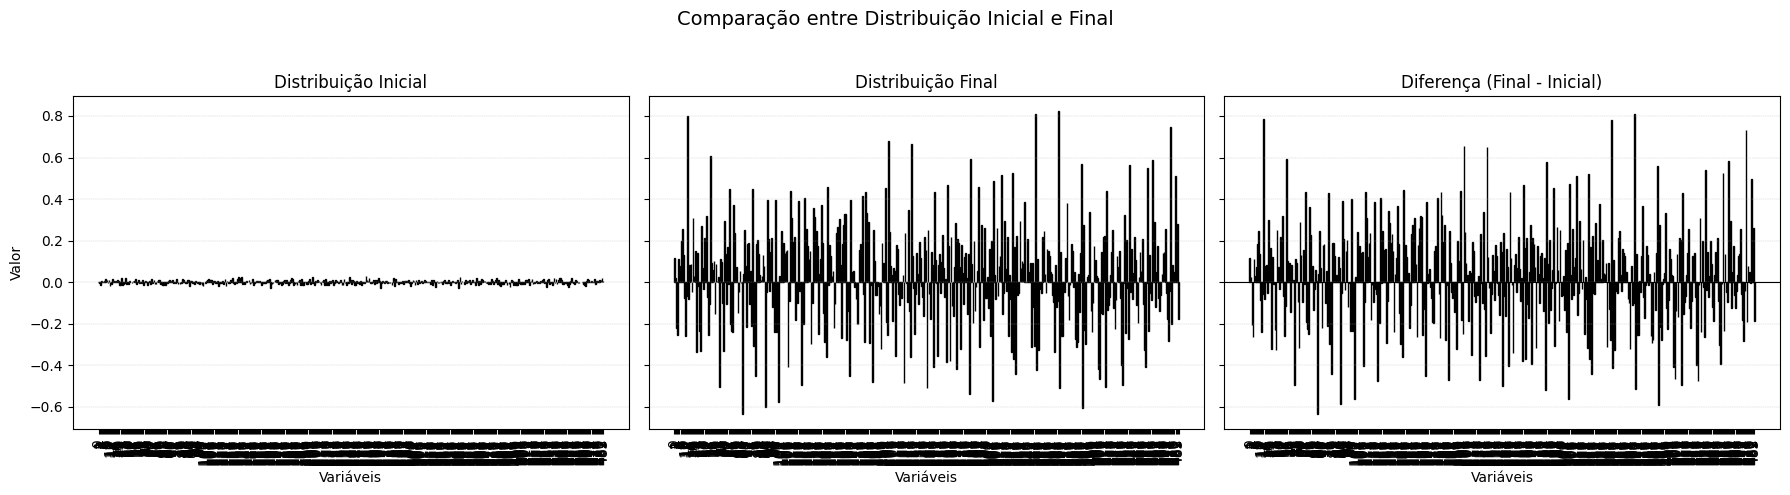

In [216]:
# Pega a primeira e última linha, ignorando a primeira coluna
linha1 = df.iloc[0].iloc[1:]
ultima_linha = df.iloc[-1].iloc[1:]

# Calcula a diferença entre as linhas
diferenca = ultima_linha - linha1

# Cria uma figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da diferença
axes[2].bar(diferenca.index, diferenca.values, 
            color=np.where(diferenca.values >= 0, 'green', 'red'),  # Verde para positivo, vermelho para negativo
            edgecolor='black')
axes[2].set_title("Diferença (Final - Inicial)", fontsize=12)
axes[2].set_xlabel("Variáveis", fontsize=10)
axes[2].tick_params(axis='x', rotation=90)
axes[2].grid(axis='y', lw=0.3, ls='--', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)  # Linha no zero para referência

# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

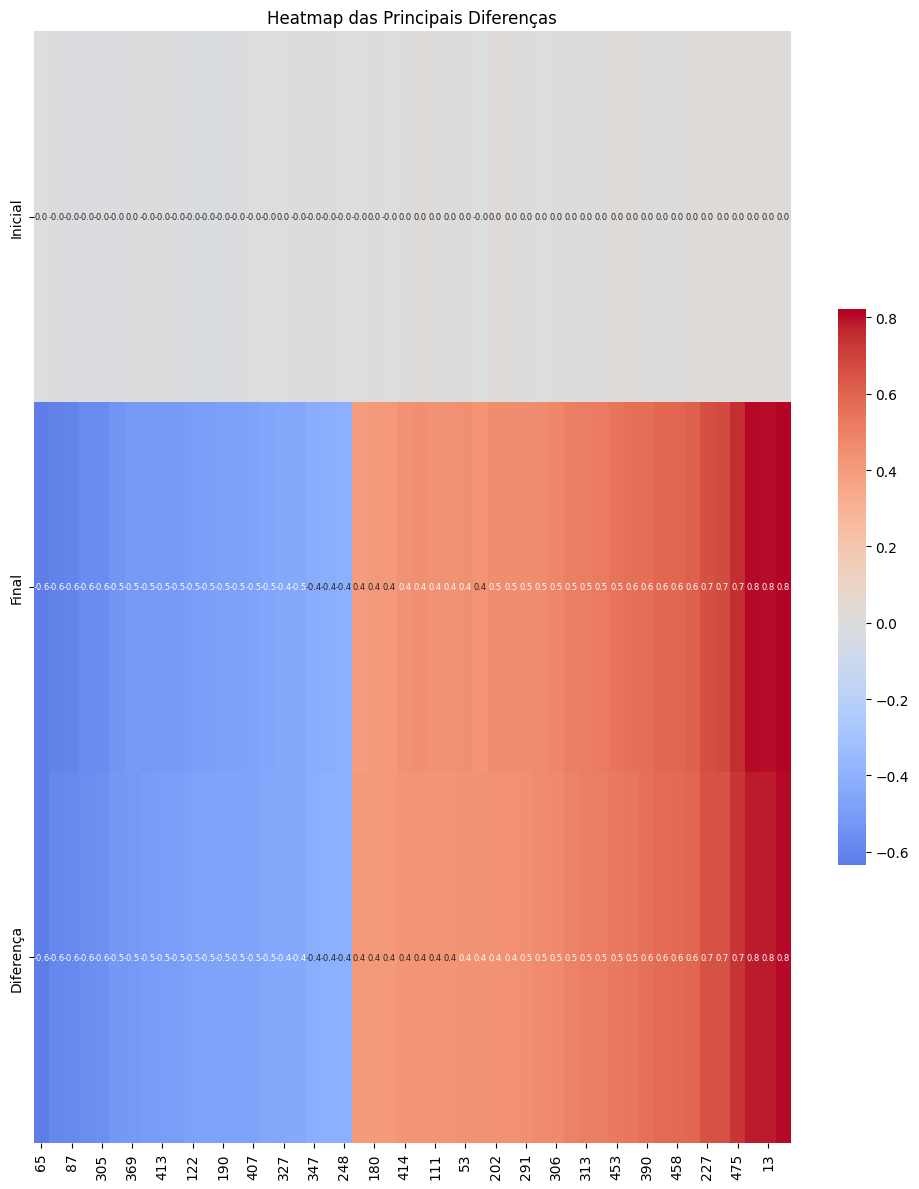

In [219]:
import seaborn as sns

# Prepara dados (exemplo para 50 colunas aleatórias)
sample_cols = diferenca.abs().nlargest(50).index
dados = pd.DataFrame({
    'Inicial': linha1[sample_cols],
    'Final': ultima_linha[sample_cols],
    'Diferença': diferenca[sample_cols]
}).sort_values('Diferença')

plt.figure(figsize=(10, 12))
sns.heatmap(dados.T, cmap="coolwarm", center=0, annot=True, fmt=".1f",
            annot_kws={'size':6}, cbar_kws={'shrink':0.5})
plt.title("Heatmap das Principais Diferenças")
plt.tight_layout()
plt.show()

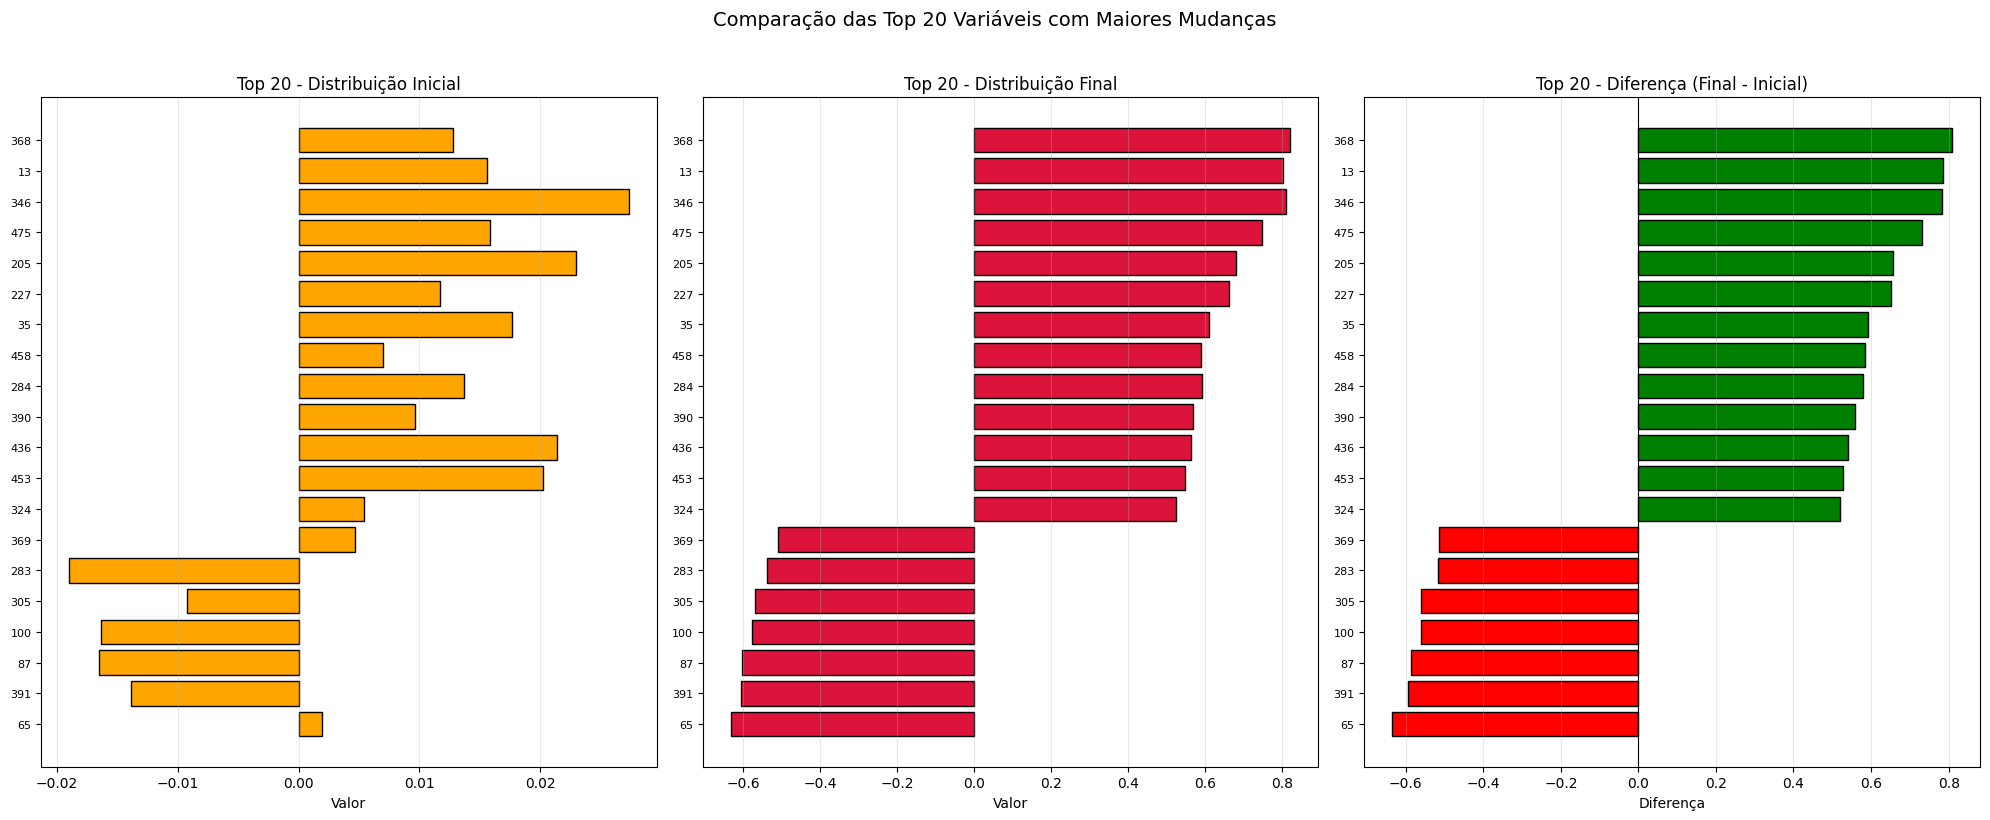

In [218]:
# Calcula as diferenças e pega as top N maiores (em valor absoluto)
diferenca = ultima_linha - linha1
top_n = 20  # Ajuste conforme necessário
top_diferencas = diferenca.abs().nlargest(top_n).index
diferenca_top = diferenca[top_diferencas]

# Ordena por valor
diferenca_top_sorted = diferenca_top.sort_values()

# Cria figura com 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Gráficos apenas para as top variáveis
# 1) Inicial
axes[0].barh(diferenca_top_sorted.index, linha1[diferenca_top_sorted.index], 
             color='orange', edgecolor='black')
axes[0].set_title(f"Top {top_n} - Distribuição Inicial")
axes[0].set_xlabel("Valor")

# 2) Final
axes[1].barh(diferenca_top_sorted.index, ultima_linha[diferenca_top_sorted.index], 
             color='crimson', edgecolor='black')
axes[1].set_title(f"Top {top_n} - Distribuição Final")
axes[1].set_xlabel("Valor")

# 3) Diferença
colors = ['green' if x >=0 else 'red' for x in diferenca_top_sorted]
axes[2].barh(diferenca_top_sorted.index, diferenca_top_sorted, 
             color=colors, edgecolor='black')
axes[2].set_title(f"Top {top_n} - Diferença (Final - Inicial)")
axes[2].set_xlabel("Diferença")
axes[2].axvline(0, color='black', linewidth=0.8)

# Ajustes comuns
for ax in axes:
    ax.grid(axis='x', alpha=0.3)
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle(f"Comparação das Top {top_n} Variáveis com Maiores Mudanças", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

In [212]:
df = pd.read_csv(paths[0])

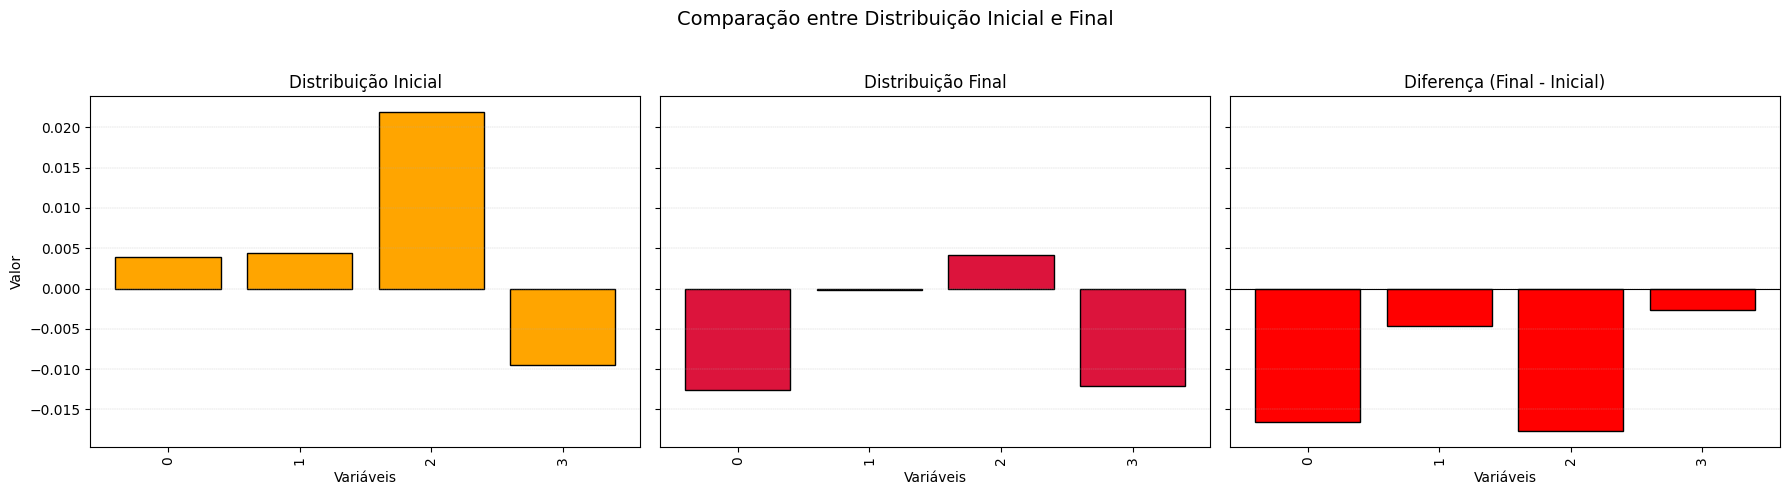

In [213]:
linha1 = df.iloc[0].iloc[1:]
ultima_linha = df.iloc[-1].iloc[1:]

# Calcula a diferença entre as linhas
diferenca = ultima_linha - linha1

# Cria uma figura com 3 subplots lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Gráfico da primeira linha
axes[0].bar(linha1.index, linha1.values, color='orange', edgecolor='black')
axes[0].set_title("Distribuição Inicial", fontsize=12)
axes[0].set_xlabel("Variáveis", fontsize=10)
axes[0].set_ylabel("Valor", fontsize=10)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da última linha
axes[1].bar(ultima_linha.index, ultima_linha.values, color='crimson', edgecolor='black')
axes[1].set_title("Distribuição Final", fontsize=12)
axes[1].set_xlabel("Variáveis", fontsize=10)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', lw=0.3, ls='--', alpha=0.7)

# Gráfico da diferença
axes[2].bar(diferenca.index, diferenca.values, 
            color=np.where(diferenca.values >= 0, 'green', 'red'),  # Verde para positivo, vermelho para negativo
            edgecolor='black')
axes[2].set_title("Diferença (Final - Inicial)", fontsize=12)
axes[2].set_xlabel("Variáveis", fontsize=10)
axes[2].tick_params(axis='x', rotation=90)
axes[2].grid(axis='y', lw=0.3, ls='--', alpha=0.7)
axes[2].axhline(0, color='black', linewidth=0.8)  # Linha no zero para referência

# Layout final
plt.suptitle("Comparação entre Distribuição Inicial e Final", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
df_kernel_real = pd.read_csv(paths[2])
linha1 = df.iloc[0]; linha1 = linha1.iloc[1:]; 
linha1.plot(kind='bar', figsize=(10, 4), color='orange')
plt.title("Distribuição de valores na primeira interação")
plt.xlabel("Variáveis"); plt.ylabel("Valor"); plt.grid(axis='y');plt.tight_layout()
plt.show()

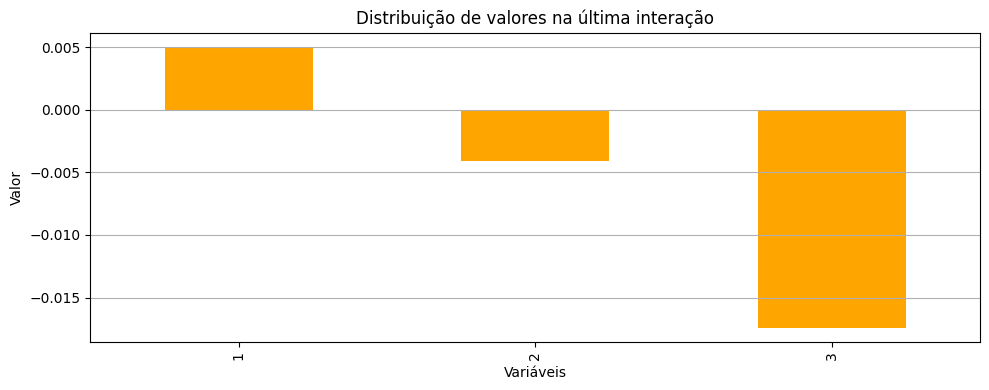

In [196]:
ultima_linha = df.iloc[-1]; ultima_linha = linha1.iloc[1:]; 
ultima_linha.plot(kind='bar', figsize=(10, 4), color='orange')
plt.title("Distribuição de valores na última interação")
plt.xlabel("Variáveis"); plt.ylabel("Valor"); plt.grid(axis='y');plt.tight_layout()
plt.show()

In [188]:
df_kernel_real.head()

,id,0,1,2,3,4,5,6,7,8,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,1,-0.00151,-0.00497,0.005075,-0.012056,0.0152,0.000033,-0.009322,0.003478,0.00451,...,-0.002164,0.001262,-0.010525,-0.007134,0.005567,0.005483,0.001114,-0.007591,-0.01086,0.001519


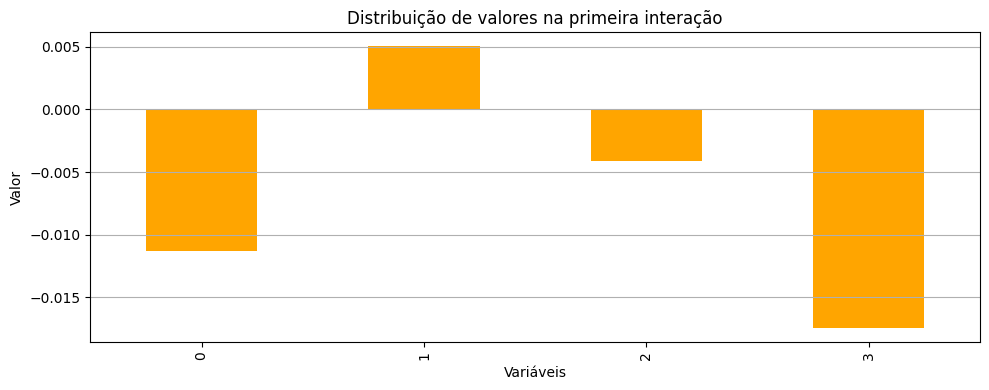

In [177]:
print(df_bias.columns)
print(df_bias.shape)
print(float(g_run_cc_energy.energy.mean.real))

Index(['id', '0', '1', '2', '3', '4', '5'], dtype='object')
(1210, 7)
-0.9880961905364339


In [178]:
L = 2; it = 100; trained_params_list = []; parameters_list = [];iii = [] 
g_run_cc_energy,r_out, paths = rbm_fe(0,L,it,False,1)

  0%|                                                             | 0/100 [00:00<?, ?it/s]

In [179]:
paths

['data/rbm_2_100_bias_real.csv',
 'data/rbm_2_100_bias_img.csv',
 'data/rbm_2_100_kernel_real.csv',
 'data/rbm_2_100_kernel_img.csv']

In [180]:
df_i = pd.read_csv(paths[0])

In [181]:
df_i.shape

(100, 3)

In [182]:
df_r = pd.read_csv(paths[2])

In [183]:
df_r.shape

(100, 5)

In [102]:
df_kernel.shape

(1300, 13)

In [103]:
df_bias.head(20)

,id,0,1,2,3,4,5
0,1,0.005728,-0.005654,0.006070,0.007720,0.001891,-0.013319
1,2,0.005725,-0.005652,0.006074,0.007717,0.001895,-0.013318
2,3,0.005726,-0.005631,0.006086,0.007706,0.001899,-0.013315
3,4,0.005732,-0.005596,0.006103,0.007693,0.001901,-0.013312
4,5,0.005731,-0.005594,0.006098,0.007692,0.001901,-0.013312
5,6,0.005732,-0.005521,0.006135,0.007657,0.001913,-0.013302
6,7,0.005734,-0.005504,0.006125,0.007652,0.001912,-0.013302
7,8,0.005735,-0.005462,0.006119,0.007635,0.001913,-0.013299
8,9,0.005740,-0.005283,0.006192,0.007550,0.001939,-0.013277
9,10,0.005745,-0.005097,0.006255,0.007462,0.001964,-0.013255


  0%|                                                             | 0/300 [00:00<?, ?it/s]

  0%|                                                             | 0/300 [00:00<?, ?it/s]

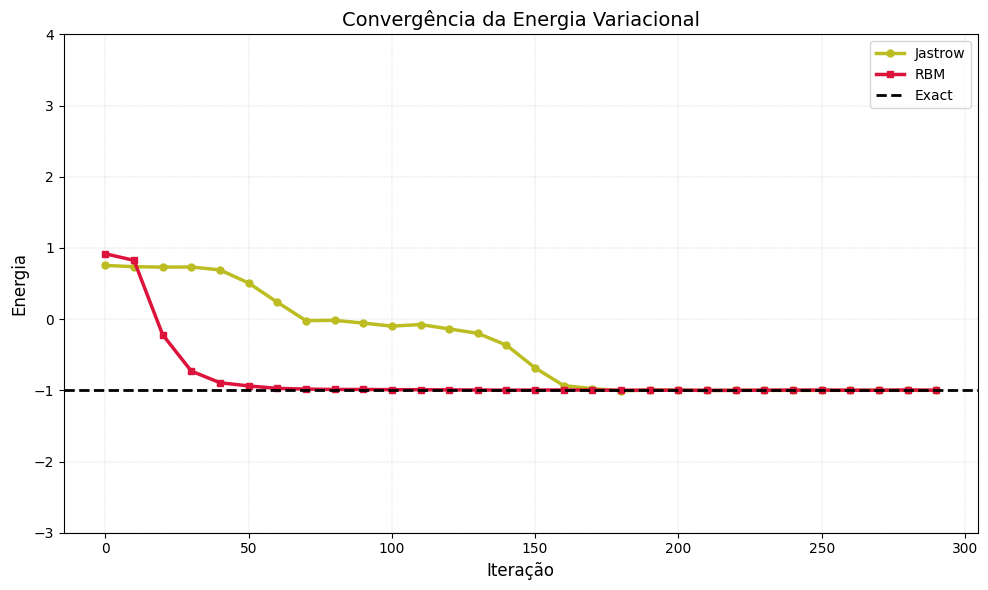

(-1.0, -0.9999862171079302, -0.9990202230649408)

In [69]:
L = 2; it = 300
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
calc_j_gs_energy,j_out = jastrow_calc(0,L,it,True)
g_run_cc_energy,r_out = rbm_fe(0,L,it,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)
(float(exact_gs_energy),float(calc_j_gs_energy), float(g_run_cc_energy.energy.mean.real))

In [70]:
df_bias = pd.read_csv('data/rbm_2_300_bias_real.csv')
print(df_bias.columns)
print(df_bias.shape)
df_bias.head()

Index(['id', '0', '1', '2', '3', '4', '5'], dtype='object')
(1210, 7)


,id,0,1,2,3,4,5
0,1,0.005728,-0.005654,0.006070,0.007720,0.001891,-0.013319
1,2,0.005725,-0.005652,0.006074,0.007717,0.001895,-0.013318
2,3,0.005726,-0.005631,0.006086,0.007706,0.001899,-0.013315
3,4,0.005732,-0.005596,0.006103,0.007693,0.001901,-0.013312
4,5,0.005731,-0.005594,0.006098,0.007692,0.001901,-0.013312


In [71]:
len(df_bias)

1210

In [50]:
df_kernel = pd.read_csv('data/rbm_2_600_kernel_real.csv')
print(df_kernel.columns)
print(df_kernel.shape)
df_kernel.head()

Index(['id', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11'], dtype='object')
(1300, 13)


,id,0,1,2,3,4,5,6,7,8,9,10,11
0,1,-0.017731,0.003202,-0.007943,-0.005105,-0.003713,0.003824,0.017146,0.000028,0.015000,0.005090,0.003866,0.023259
1,2,-0.011029,0.003209,-0.002076,-0.003129,-0.002196,0.012937,0.010206,0.001281,0.011890,0.003090,0.002413,0.024757
2,3,-0.007001,0.003714,0.002617,-0.001912,-0.001243,0.022708,0.005847,0.002546,0.011067,0.001845,0.001547,0.029866
3,4,-0.004736,0.004699,0.006924,-0.001225,-0.000634,0.034366,0.003110,0.003991,0.012084,0.001086,0.001065,0.038722
4,5,-0.003539,0.006240,0.011598,-0.000819,-0.000219,0.049342,0.001273,0.005809,0.014762,0.000605,0.000821,0.052006


  0%|                                                             | 0/600 [00:00<?, ?it/s]

  0%|                                                             | 0/600 [00:00<?, ?it/s]

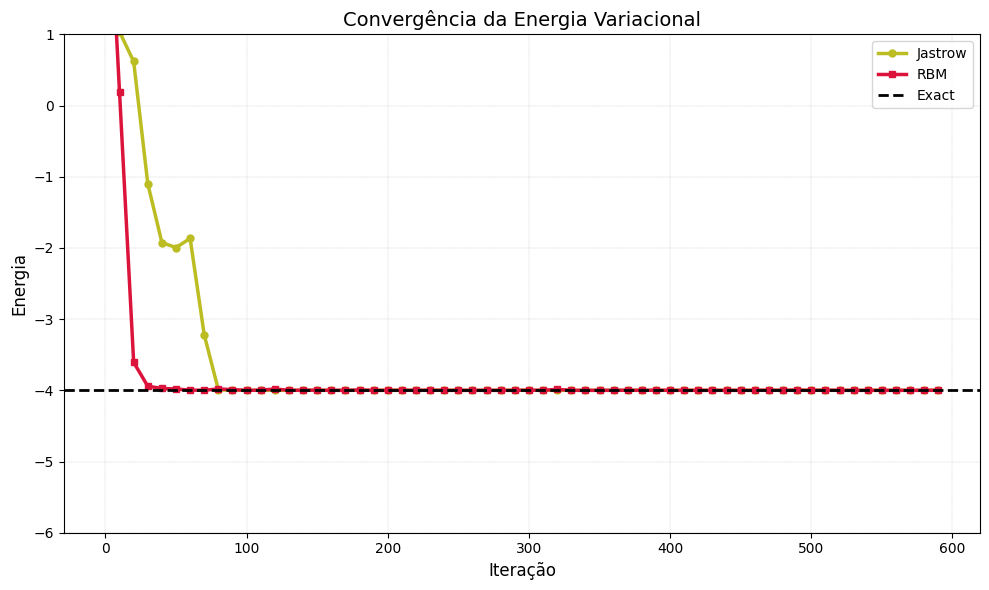

In [7]:
L = 4
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

  0%|                                                             | 0/600 [00:00<?, ?it/s]

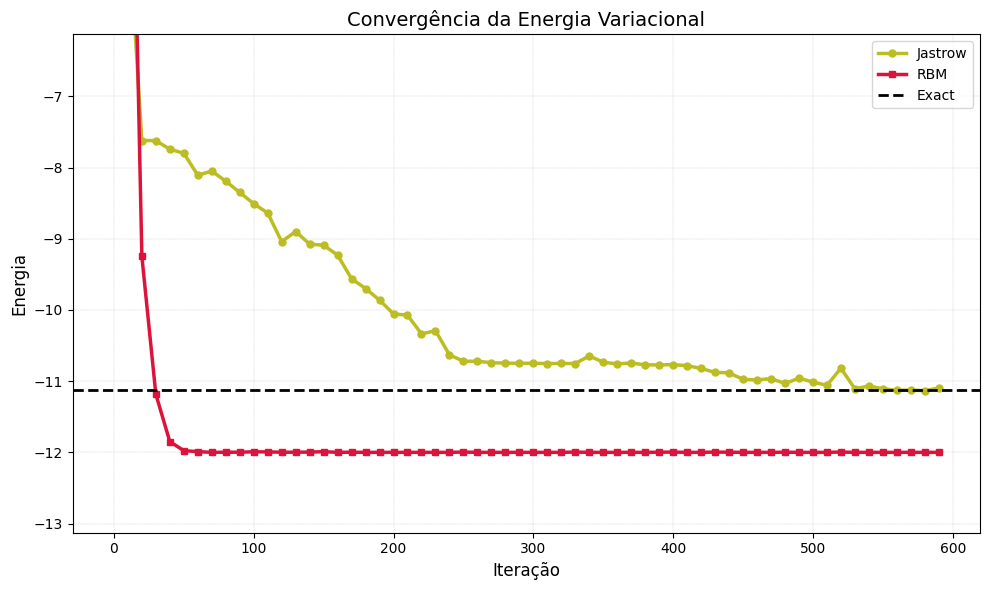

In [8]:
L = 12
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

  0%|                                                             | 0/600 [00:00<?, ?it/s]

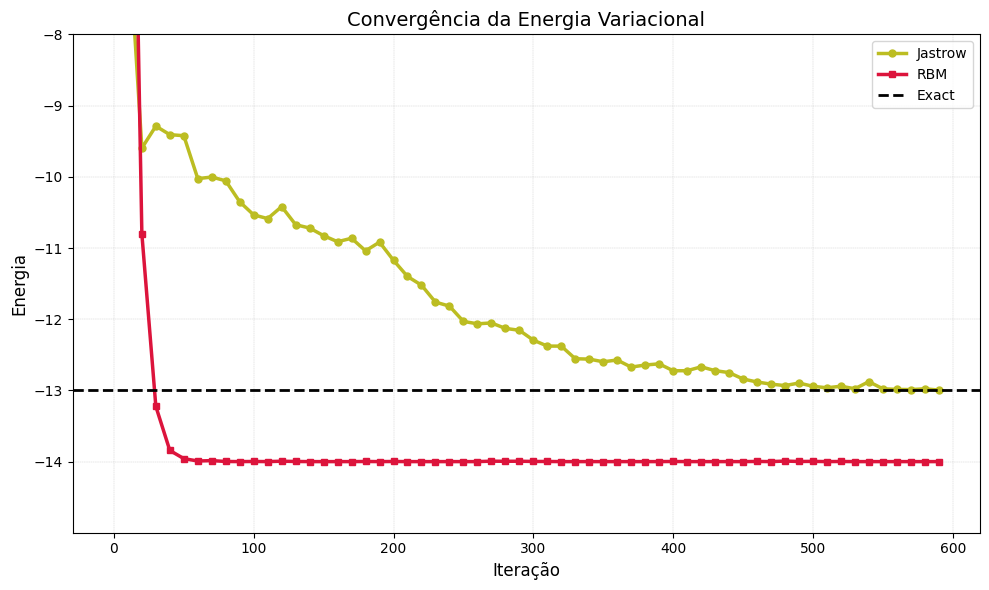

In [10]:
L = 14
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

  0%|                                                             | 0/600 [00:00<?, ?it/s]

  0%|                                                             | 0/600 [00:00<?, ?it/s]

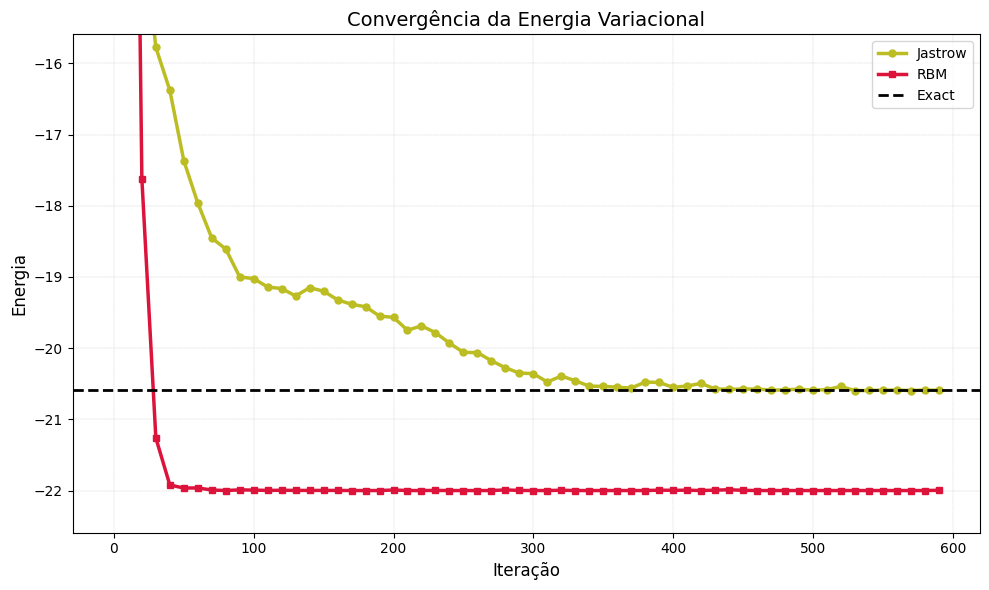

In [9]:
L = 22
mens, exact_gs_energy = exac_calc_lanczos_ed(0,L, True)
exact_gs_energy,j_out = jastrow_calc(0,L,600,True)
g_run_cc_energy,r_out = rbm_fe(0,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

In [ ]:
L = 2
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

In [ ]:
L = 4
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

#### L = 12

In [ ]:
L = 12
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)
files = [] ; files.append(j_out);files.append(r_out);files
plot(exact_gs_energy,files)

#### L = 22

In [ ]:
L = 22
mens, exact_gs_energy = exac_calc_lanczos_ed(1,L, True)
exact_gs_energy,j_out = jastrow_calc(1,L,600,True)
g_run_cc_energy,r_out = rbm(1,L,600,True)

In [ ]:
files = [] ; files.append(j_out);files.append(r_out);files

In [ ]:
%run 0_config.ipynb

In [ ]:
plot(exact_gs_energy,files)